## 掛載雲端硬碟


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

## 更改檔案所在路徑

In [ ]:
# # Change to your own folder !!!
# %cd /content/drive/MyDrive/your own folder/

## Import library

In [8]:
import os
import argparse
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.autograd import Variable

from models.resnet import ResNet50

## 設定超參數

In [2]:
SEED = 43
TRAIN_BATCH_SIZE = 100
TEST_BATCH_SIZE = 1000
EPOCHS = 100
LEARNING_RATE = 1e-3
LOG_INTERVAL = 100
CUDA = True

RESUME = True
START_EPOCH = 0

PRUNE_PATH = './out/model_prune.pth' # Change to your own folder !!!
PRUNE_FINETUNE_PATH = "./out/model_prune_finetune.pth"  # Change to your own folder !!!

#### 檢查是否檢查是否可使用GPU

In [4]:
if(torch.cuda.is_available()):
    CUDA = True
    kwargs = {'num_workers': 4, 'pin_memory': True}
    torch.cuda.manual_seed(SEED)
else:
    CUDA = False
    kwargs = {}


## 下載資料集


這裡將訓練集做Augmentation(Pad, RandCrop, Random)，測試集不用做Augmentation

In [5]:
#### DATASET ####
train_loader = torch.utils.data.DataLoader(
    datasets.CIFAR10('./data', train=True, download=True,
                   transform=transforms.Compose([
                       transforms.Pad(4),
                       transforms.RandomCrop(32),
                       transforms.RandomHorizontalFlip(),
                       transforms.ToTensor(),
                       transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
                   ])),
    batch_size=TRAIN_BATCH_SIZE, shuffle=True, **kwargs)
test_loader = torch.utils.data.DataLoader(
    datasets.CIFAR10('./data', train=False, transform=transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
                   ])),
    batch_size=TEST_BATCH_SIZE, shuffle=True, **kwargs)

Files already downloaded and verified


## 載入剪枝後的網路與權重

In [6]:
model = None
if(RESUME):
  checkpoint = torch.load(PRUNE_PATH)
  cfg = checkpoint['cfg']
  model = ResNet50(num_classes=10,cfg=cfg)
  model.load_state_dict(checkpoint['state_dict'])

  print('RESUME PRUNE MODEL')

if CUDA:
    model.cuda()

/tmp/ipykernel_1629/3319477126.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(PRUNE_PATH)


Total cfg used: 0
RESUME PRUNE MODEL


## 設定 Optimizer & CrossEntropy Loss

In [7]:
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

## 定義訓練跟測試函數

In [9]:
# ==========================================================
# 設定與初始化
# ==========================================================
os.makedirs("./out", exist_ok=True)

train_acc_list = []
val_acc_list = []


# ==========================================================
# 訓練函數
# ==========================================================
def train(epoch):
    model.train()
    correct = 0
    total = 0
    running_loss = 0.0

    for batch_idx, (data, target) in enumerate(train_loader):
        if CUDA:
            data, target = data.cuda(), target.cuda()
        data, target = Variable(data), Variable(target)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        # === 計算 accuracy ===
        pred = output.data.max(1, keepdim=True)[1]
        correct += pred.eq(target.data.view_as(pred)).sum().item()
        total += target.size(0)
        running_loss += loss.item() * data.size(0)

        if batch_idx % LOG_INTERVAL == 0:
            print(
                "\nTrain Epoch: {} [{}/{} ({:.1f}%)]\tLoss: {:.6f}".format(
                    epoch,
                    batch_idx * len(data),
                    len(train_loader.dataset),
                    100.0 * batch_idx / len(train_loader),
                    loss.data.item(),
                )
            )

    acc = 100.0 * correct / total
    avg_loss = running_loss / total
    train_acc_list.append(acc)
    print(f"Epoch {epoch}: Train Loss={avg_loss:.4f}, Train Acc={acc:.2f}%")


# ==========================================================
# 測試函數
# ==========================================================
def test():
    model.eval()
    test_loss = 0
    correct = 0

    with torch.no_grad():
        for data, target in test_loader:
            if CUDA:
                data, target = data.cuda(), target.cuda()
            data, target = Variable(data), Variable(target)

            output = model(data)
            loss = criterion(output, target)
            test_loss += loss.item() * data.size(0)

            pred = output.data.max(1, keepdim=True)[1]
            correct += pred.eq(target.data.view_as(pred)).cpu().sum().item()

    test_loss /= len(test_loader.dataset)
    acc = 100.0 * correct / len(test_loader.dataset)
    val_acc_list.append(acc)
    print(f"\nTest set: Avg loss: {test_loss:.4f}, Accuracy: {acc:.2f}%\n")
    return acc / 100.0


# ==========================================================
# Fine-tuning 主流程
# ==========================================================
best_prec1 = 0.0
for epoch in range(START_EPOCH, EPOCHS):
    # Learning Rate 在 0.5EPOCHS 與 0.75EPOCHS 時降為原本十分之一
    if epoch == int(EPOCHS * 0.5) or epoch == int(EPOCHS * 0.75):
        for param_group in optimizer.param_groups:
            param_group["lr"] *= 0.1
            print(f"[LR Update] Epoch {epoch}: lr -> {param_group['lr']}")
    train(epoch)
    prec1 = test()

    # 儲存最佳模型權重
    if prec1 > best_prec1:
        best_prec1 = prec1
        torch.save(
            {
                "epoch": epoch + 1,
                "state_dict": model.state_dict(),
                "best_prec1": best_prec1,
                "optimizer": optimizer.state_dict(),
                "cfg": cfg if "cfg" in globals() else None,
            },
            PRUNE_FINETUNE_PATH,
        )
        print(f"[Model Saved] New best acc: {best_prec1:.2%}")

np.save("./out/train_acc.npy", np.array(train_acc_list))
np.save("./out/val_acc.npy", np.array(val_acc_list))
print("Train/test accuracy logs saved!")

print("\nTRAIN PRUNED MODEL DONE!")


Train Epoch: 0 [0/50000 (0.0%)]	Loss: 0.967499

Train Epoch: 0 [10000/50000 (20.0%)]	Loss: 0.376419

Train Epoch: 0 [20000/50000 (40.0%)]	Loss: 0.200972

Train Epoch: 0 [30000/50000 (60.0%)]	Loss: 0.229383

Train Epoch: 0 [40000/50000 (80.0%)]	Loss: 0.348503
Epoch 0: Train Loss=0.3187, Train Acc=89.05%

Test set: Avg loss: 0.4492, Accuracy: 86.25%

[Model Saved] New best acc: 86.25%

Train Epoch: 1 [0/50000 (0.0%)]	Loss: 0.240108

Train Epoch: 1 [10000/50000 (20.0%)]	Loss: 0.240776

Train Epoch: 1 [20000/50000 (40.0%)]	Loss: 0.265055

Train Epoch: 1 [30000/50000 (60.0%)]	Loss: 0.255175

Train Epoch: 1 [40000/50000 (80.0%)]	Loss: 0.123062
Epoch 1: Train Loss=0.2487, Train Acc=91.58%

Test set: Avg loss: 0.4364, Accuracy: 86.99%

[Model Saved] New best acc: 86.99%

Train Epoch: 2 [0/50000 (0.0%)]	Loss: 0.262420

Train Epoch: 2 [10000/50000 (20.0%)]	Loss: 0.232040

Train Epoch: 2 [20000/50000 (40.0%)]	Loss: 0.151307

Train Epoch: 2 [30000/50000 (60.0%)]	Loss: 0.233348

Train Epoch: 2 [40

## 繪製Fine-tuning結果圖


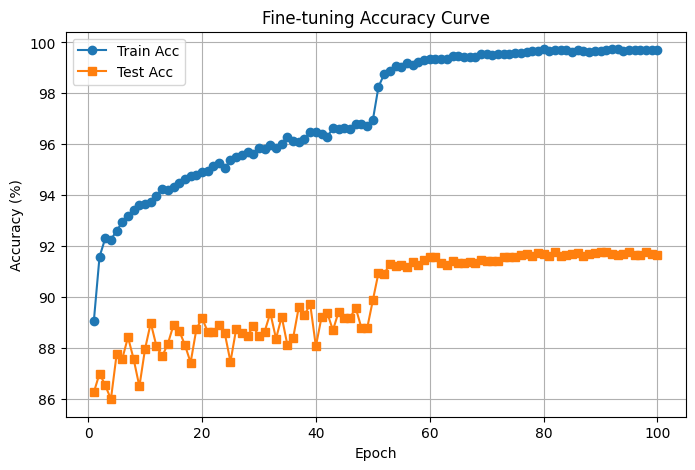

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(train_acc_list) + 1), train_acc_list, label="Train Acc", marker="o"
)
plt.plot(range(1, len(val_acc_list) + 1), val_acc_list, label="Test Acc", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Fine-tuning Accuracy Curve")
plt.legend()
plt.grid(True)
plt.savefig("./out/finetune_acc_curve.png", dpi=300)
plt.show()

## FLOPs & Parameters

In [ ]:
# %pip install thop torchsummary -q

In [11]:
from thop import profile
from torchsummary import summary

##### 使用 thop 計算 FLOPs 和參數數量 #####
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
model = model.to(device)

dummy_input = torch.randn(1, 3, 32, 32).to(device)
flops, params = profile(model, inputs=(dummy_input, ))

print(f"FLOPs: {flops}")
print(f"Params: {params}")
summary(model, input_size=(3, 32, 32))

Device: cuda
[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.MaxPool2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register count_adap_avgpool() for <class 'torch.nn.modules.pooling.AdaptiveAvgPool2d'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
FLOPs: 125798688.0
Params: 3653771.0
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,728
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
         MaxPool2d-4           [-1, 64, 16, 16]           